<a href="https://colab.research.google.com/github/marcusslongweek/Homework/blob/main/CS4410HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Downloading Hamlet

In [6]:
!pip install requests

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import requests

target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

In [8]:
from textblob import TextBlob

blob = TextBlob(data)

### Getting the Word Frequencies

In [9]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

In [10]:
nltk.download('punkt_tab')
items = blob.word_counts.items()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Removing Stop Words

In [11]:
items = [item for item in items if item[0] not in stop_words]

### Sorting the Words by Frequency

In [12]:
from operator import itemgetter

sorted_items = sorted(items, key=itemgetter(1), reverse=True)

In [13]:
sorted_items[:25]

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68),
 ('loue', 65),
 ('vs', 64),
 ('sir', 62),
 ('qu', 62),
 ('laer', 60)]

### Getting the Top 20 Words

In [14]:
# Ignore the apostrophe if TextBlob counts it as a word
if sorted_items[0][0] in {"'", "’"}:
    top20 = sorted_items[1:21]
else:
    top20 = sorted_items[:20]

top20

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68)]

### Creating the DataFrame

In [15]:
import pandas as pd

df = pd.DataFrame(top20, columns=['word', 'count'])
df

,word,count
0,ham,337
1,lord,211
2,haue,175
3,king,173
4,shall,107
5,come,106
6,thou,105
7,let,104
8,hamlet,100
9,good,98


### Visualizing the Top 20 Words

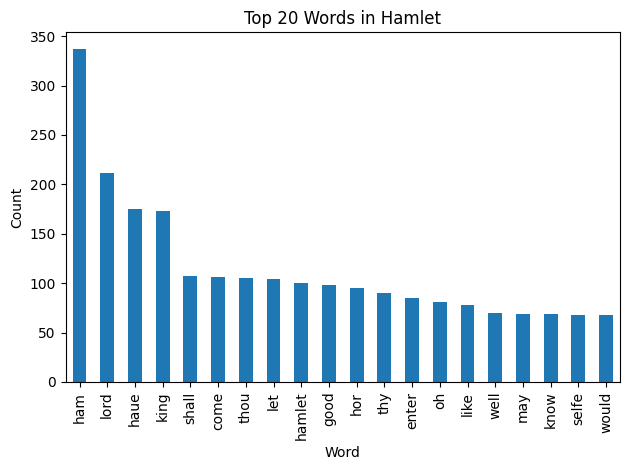

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

axes = df.plot.bar(x='word', y='count', legend=False)
axes.set_title('Top 20 Words in Hamlet')
axes.set_xlabel('Word')
axes.set_ylabel('Count')

plt.gcf().tight_layout()

### Creating the Word Cloud

In [17]:
import imageio

image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

In [18]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=1000, height=1000,
    colormap='prism', mask=mask_image, background_color='white')

In [19]:
wordcloud = wordcloud.generate(data)

In [20]:
wordcloud = wordcloud.to_file('HamletWordCloud.png')

### Displaying the Word Cloud

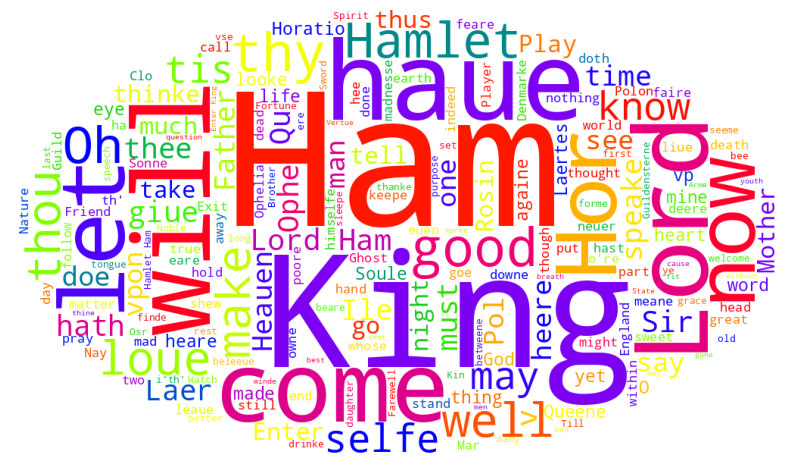

In [21]:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()